# TF vs PyTorch: **P** and **S** on the same SeisBench windows

Loads `modelP` / `modelS` (TensorFlow) and `EQCCTModelP` / `EQCCTModelS` (PyTorch), builds **one shared** `(1, 6000, 3)` window per shuffle seed, and compares pickers. Data and normalization match the separate P/S demos (`component_order="ZNE"`, per-window time normalization).

**Windowing:** traces must have **both** catalog P and S. The slice is **centered on catalog P** (same idea as `tf_pt_p_waveform_picking_demo.ipynb`); traces where **S** does not fall inside that 6000-sample window are skipped for that shuffle so both catalog lines are visible.

Each seed produces one figure: **Z, N, E** waveforms (with catalog P / S markers) then **P** probabilities (TF vs PT) then **S** probabilities (TF vs PT).

Requires `seisbench`. If `import seisbench` fails on `pkg_resources`, run `pip install 'setuptools>=69,<81'`.

Optional checkpoints:

```bash
PYTHONPATH=. python -m validation.tf_pt_p_trace \
  --p-h5 ModelPS/test_trainer_024.h5 --s-h5 ModelPS/test_trainer_021.h5 \
  --skip-weights --skip-activations --save-model ModelPS/eqcct_model_p.pt
PYTHONPATH=. python -m validation.tf_pt_s_trace \
  --p-h5 ModelPS/test_trainer_024.h5 --s-h5 ModelPS/test_trainer_021.h5 \
  --skip-weights --skip-activations --save-model ModelPS/eqcct_model_s.pt
```

TensorFlow is restricted to **CPU** in the model cell (same rationale as the P/S single-model demos).

In [1]:
from pathlib import Path
import os
import sys

REPO = Path.cwd().resolve()
if REPO.name == "notebooks":
    REPO = REPO.parent
os.chdir(REPO)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

P_H5 = REPO / "ModelPS" / "test_trainer_024.h5"
S_H5 = REPO / "ModelPS" / "test_trainer_021.h5"
PT_P_CKPT = REPO / "ModelPS" / "eqcct_model_p.pt"
PT_S_CKPT = REPO / "ModelPS" / "eqcct_model_s.pt"

print("REPO", REPO)
print("P_H5", P_H5.is_file(), "S_H5", S_H5.is_file())
print("PT P ckpt", PT_P_CKPT.is_file(), "PT S ckpt", PT_S_CKPT.is_file())

REPO /home/skevofilaxc/workspace/EQCCT_to_Seisbench
P_H5 True S_H5 True
PT P ckpt True PT S ckpt True


In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import tensorflow as tf

try:
    tf.config.set_visible_devices([], "GPU")
except Exception:
    pass

from reference.predictor_tf import load_eqcct_model
from models.predictor_pt_p import EQCCTModelP, EQCCTModelS
from conversion.loader import load_eqcct_model_p_weights, load_eqcct_model_s_weights

model_p_tf, model_s_tf = load_eqcct_model(str(P_H5), str(S_H5))

model_p_pt = EQCCTModelP().eval()
if PT_P_CKPT.is_file():
    try:
        ck = torch.load(PT_P_CKPT, map_location="cpu", weights_only=False)
    except TypeError:
        ck = torch.load(PT_P_CKPT, map_location="cpu")
    model_p_pt.load_state_dict(ck["state_dict"])
    print("Loaded PT P from", PT_P_CKPT)
else:
    load_eqcct_model_p_weights(model_p_pt, h5_path=str(P_H5))
    print("Loaded PT P from H5", P_H5)

model_s_pt = EQCCTModelS().eval()
if PT_S_CKPT.is_file():
    try:
        ck = torch.load(PT_S_CKPT, map_location="cpu", weights_only=False)
    except TypeError:
        ck = torch.load(PT_S_CKPT, map_location="cpu")
    model_s_pt.load_state_dict(ck["state_dict"])
    print("Loaded PT S from", PT_S_CKPT)
else:
    load_eqcct_model_s_weights(model_s_pt, h5_path=str(S_H5))
    print("Loaded PT S from H5", S_H5)

print("All four models ready.")

2026-04-10 15:28:24.779789: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-10 15:28:24.779835: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-10 15:28:24.780561: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-10 15:28:25,731	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Loaded PT P from /home/skevofilaxc/workspace/EQCCT_to_Seisbench/ModelPS/eqcct_model_p.pt
Loaded PT S from /home/skevofilaxc/workspace/EQCCT_to_Seisbench/ModelPS/eqcct_model_s.pt
All four models ready.


[eqcct predictor_tf] weight load strategy: P='by_name strict', S='positional' (if not 'by_name strict', verify TF outputs against a known-good Keras version).


In [3]:
import random

import seisbench.data as sbd

SAMPLE_RATE = 100
DATASET_CHOICE = 0  # 0 = TXED, 1 = STEAD
N_SHUFFLE_SEEDS = 10
SHUFFLE_SEEDS = list(range(N_SHUFFLE_SEEDS))

if DATASET_CHOICE == 1:
    dataset = sbd.STEAD(sampling_rate=SAMPLE_RATE, component_order="ZNE")
    ds_name = "STEAD"
else:
    dataset = sbd.TXED(sampling_rate=SAMPLE_RATE, component_order="ZNE")
    ds_name = "TXED"

md = dataset.metadata
good_p = md["trace_p_arrival_sample"].notna() & (md["trace_p_arrival_sample"] > 0)
good_s = md["trace_s_arrival_sample"].notna() & (md["trace_s_arrival_sample"] > 0)
valid_names = md[good_p & good_s]["trace_name"].tolist()
print(f"{ds_name}: {len(valid_names)} traces with P and S picks")


def norm_std_time(x: np.ndarray) -> np.ndarray:
    m = x.mean(axis=1, keepdims=True)
    s = x.std(axis=1, keepdims=True) + 1e-8
    return ((x - m) / s).astype(np.float32)


def window_for_shuffle_seed(shuffle_seed: int):
    """P-centered 6000-sample window; require catalog S inside [0, 6000)."""
    names = list(valid_names)
    random.seed(shuffle_seed)
    random.shuffle(names)
    for trace_name in names:
        idx = dataset.get_idx_from_trace_name(trace_name)
        raw = np.asarray(dataset.get_waveforms([idx])[0], dtype=np.float32)
        if raw.shape[1] < 6000:
            continue
        p_sample = int(md.loc[idx, "trace_p_arrival_sample"])
        s_sample = int(md.loc[idx, "trace_s_arrival_sample"])
        start = max(0, min(p_sample - 3000, raw.shape[1] - 6000))
        p_in = p_sample - start
        s_in = s_sample - start
        if not (0 <= s_in < 6000):
            continue
        win = raw[:, start : start + 6000]
        wf = norm_std_time(win.transpose(1, 0)[np.newaxis, ...])
        return trace_name, wf, p_in, s_in, start
    raise RuntimeError("No trace in shuffled list with len≥6000 and S inside P-centered window")

TXED: 312231 traces with P and S picks


seed  0  P: max|TF-PT|=0.0000 argmax TF=598 PT=598 catP=606  |  S: max|TF-PT|=0.0000 argmax TF=1267 PT=1267 catS=1073
         trace='bucket257$255,:3,:6000'…  window_start=0


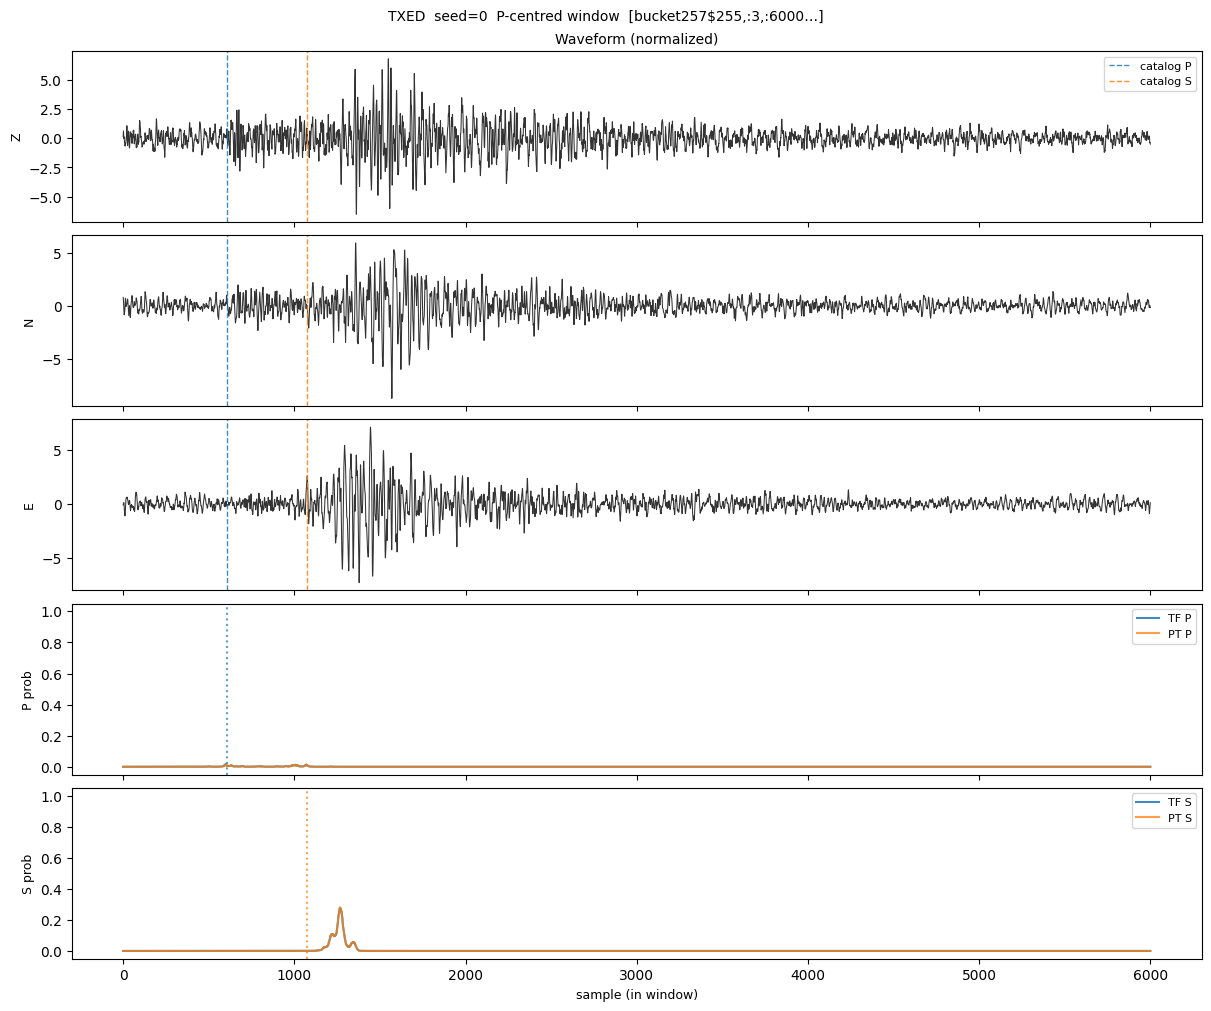

seed  1  P: max|TF-PT|=0.0000 argmax TF=1072 PT=1072 catP=1075  |  S: max|TF-PT|=0.0000 argmax TF=1429 PT=1429 catS=1394
         trace='bucket272$487,:3,:6000'…  window_start=0


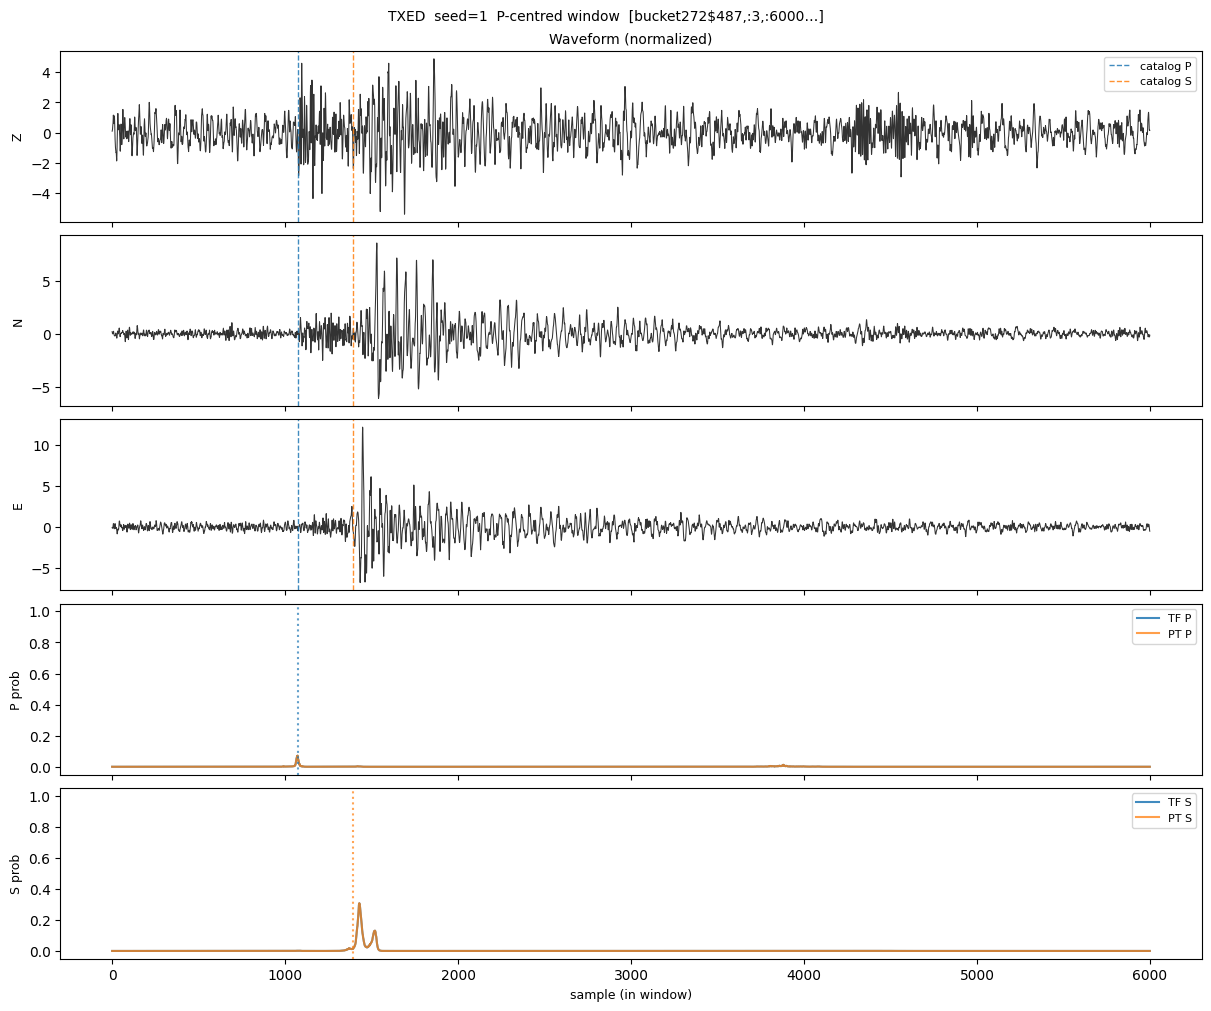

seed  2  P: max|TF-PT|=0.0000 argmax TF=638 PT=638 catP=682  |  S: max|TF-PT|=0.0000 argmax TF=1392 PT=1392 catS=1351
         trace='bucket486$427,:3,:6000'…  window_start=0


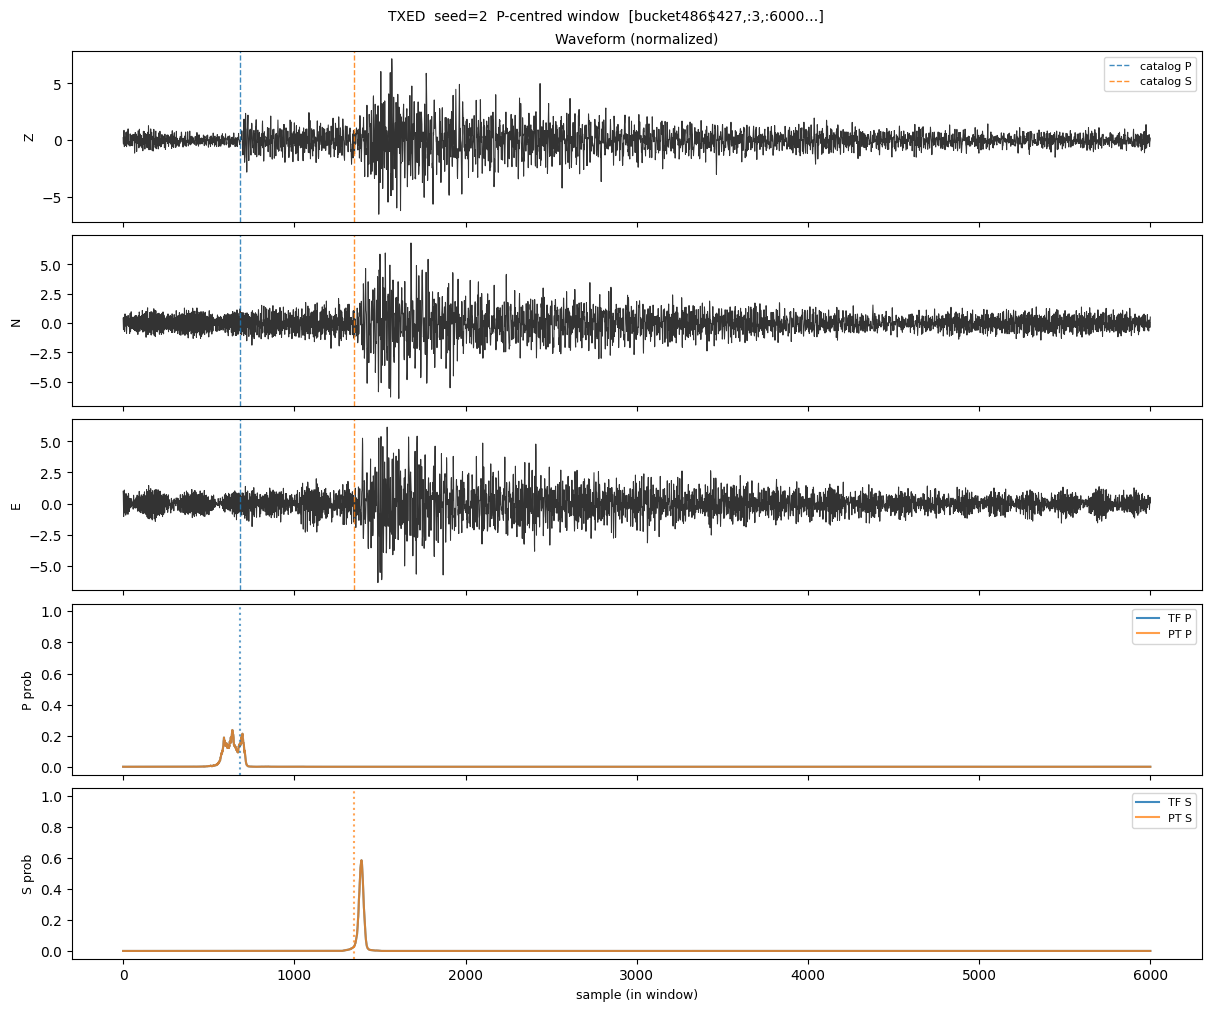

seed  3  P: max|TF-PT|=0.0000 argmax TF=406 PT=406 catP=419  |  S: max|TF-PT|=0.0000 argmax TF=1106 PT=1106 catS=1136
         trace='bucket413$369,:3,:6000'…  window_start=0


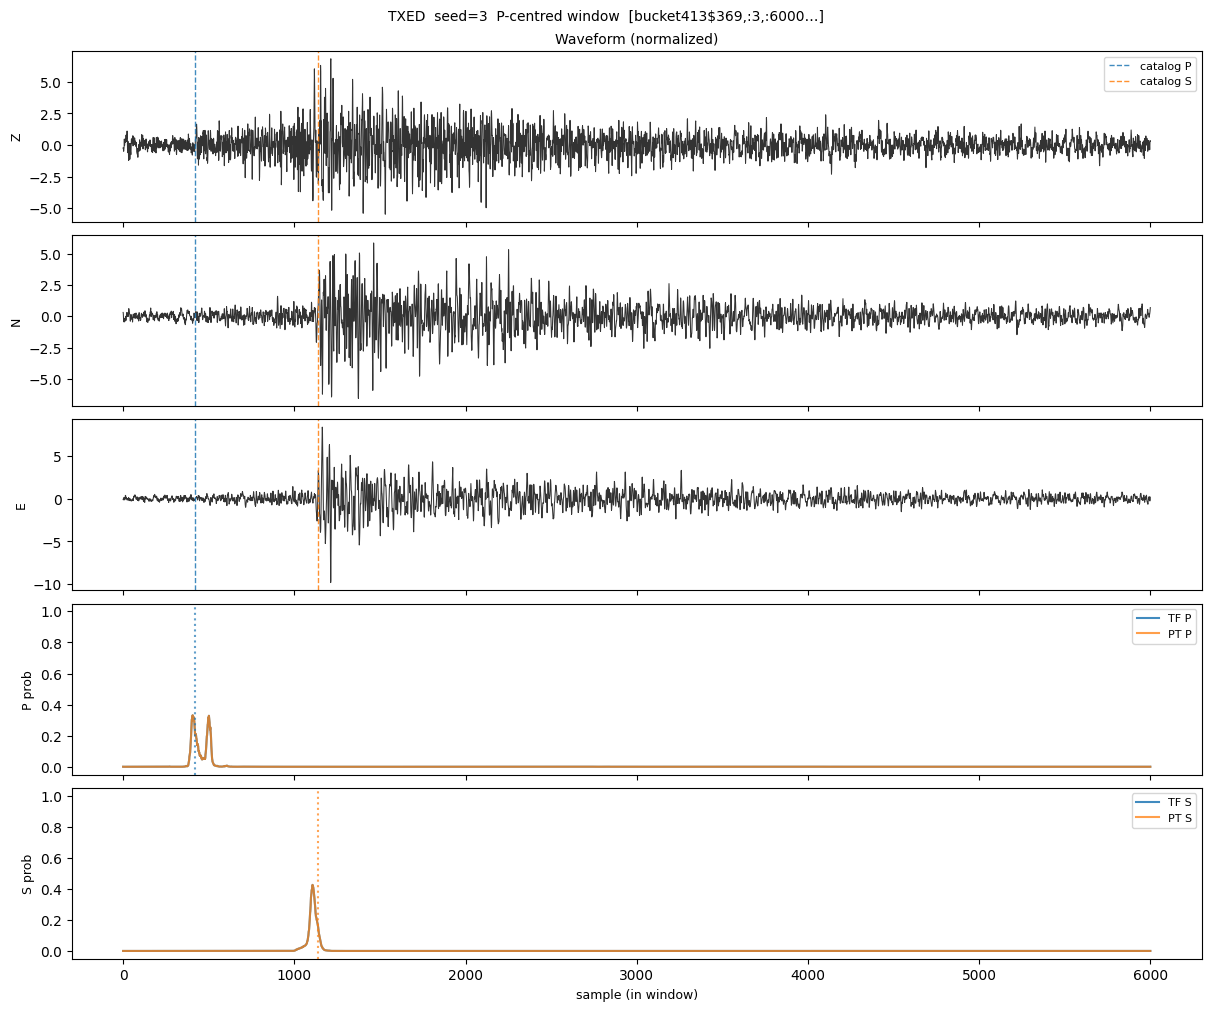

seed  4  P: max|TF-PT|=0.0000 argmax TF=500 PT=500 catP=443  |  S: max|TF-PT|=0.0000 argmax TF=672 PT=672 catS=673
         trace='bucket312$36,:3,:6000'…  window_start=0


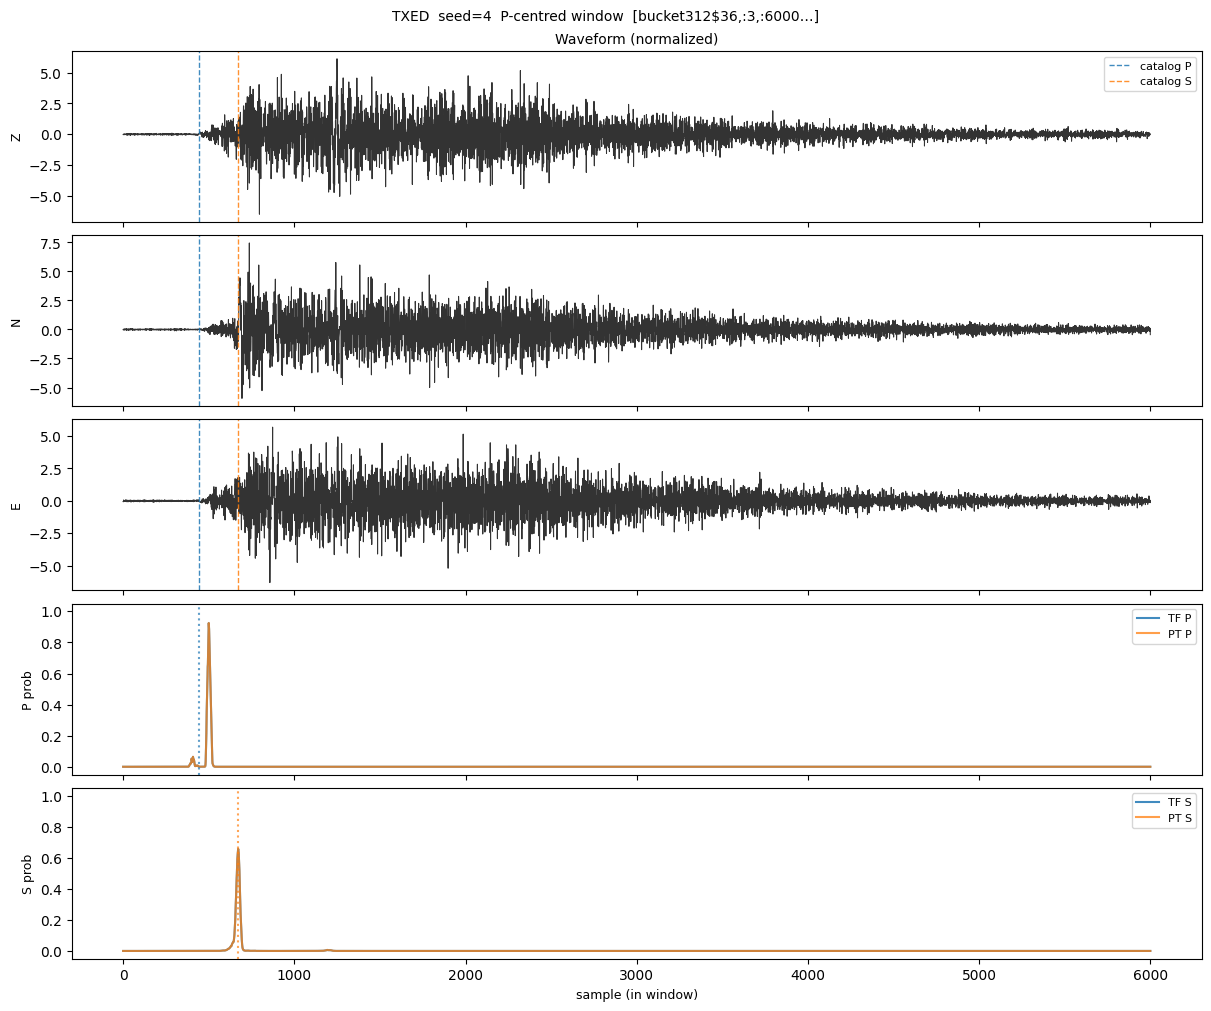

seed  5  P: max|TF-PT|=0.0000 argmax TF=0 PT=0 catP=208  |  S: max|TF-PT|=0.0000 argmax TF=0 PT=0 catS=1557
         trace='bucket242$926,:3,:6000'…  window_start=0


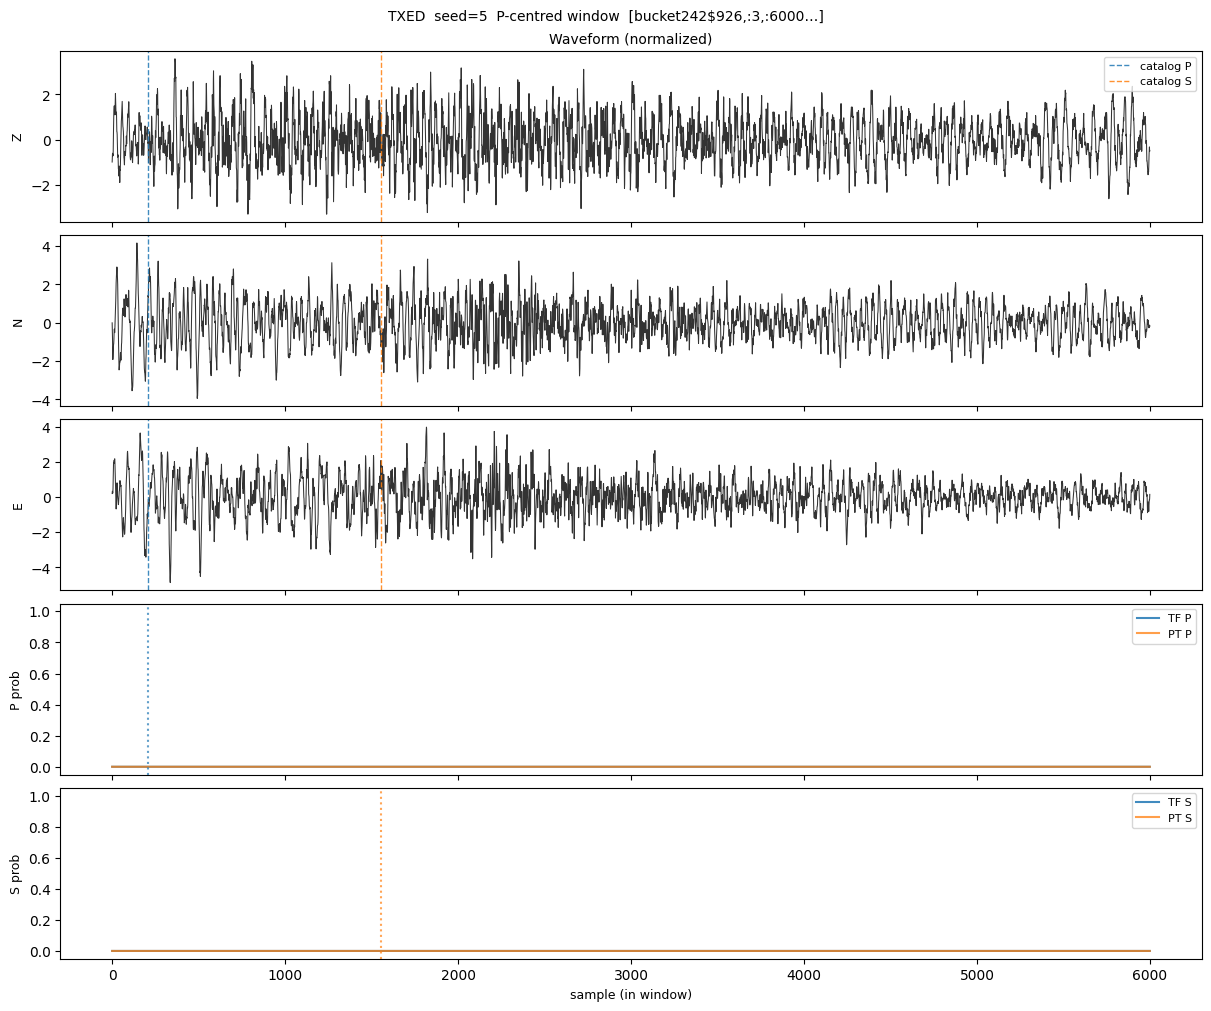

seed  6  P: max|TF-PT|=0.0000 argmax TF=700 PT=700 catP=195  |  S: max|TF-PT|=0.0000 argmax TF=941 PT=941 catS=746
         trace='bucket323$836,:3,:6000'…  window_start=0


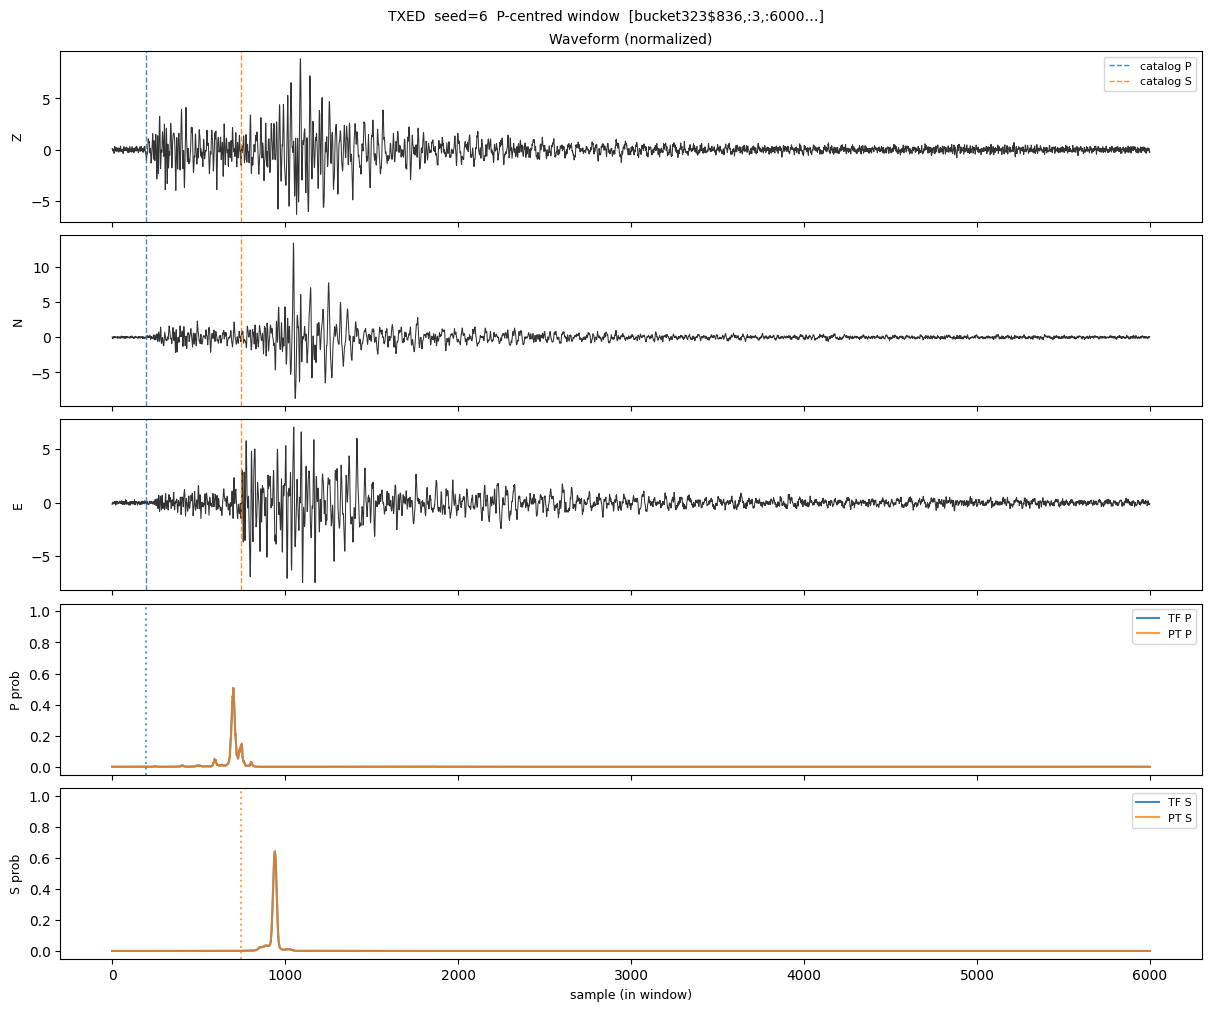

seed  7  P: max|TF-PT|=0.0000 argmax TF=408 PT=408 catP=150  |  S: max|TF-PT|=0.0000 argmax TF=1923 PT=1923 catS=1915
         trace='bucket264$474,:3,:6000'…  window_start=0


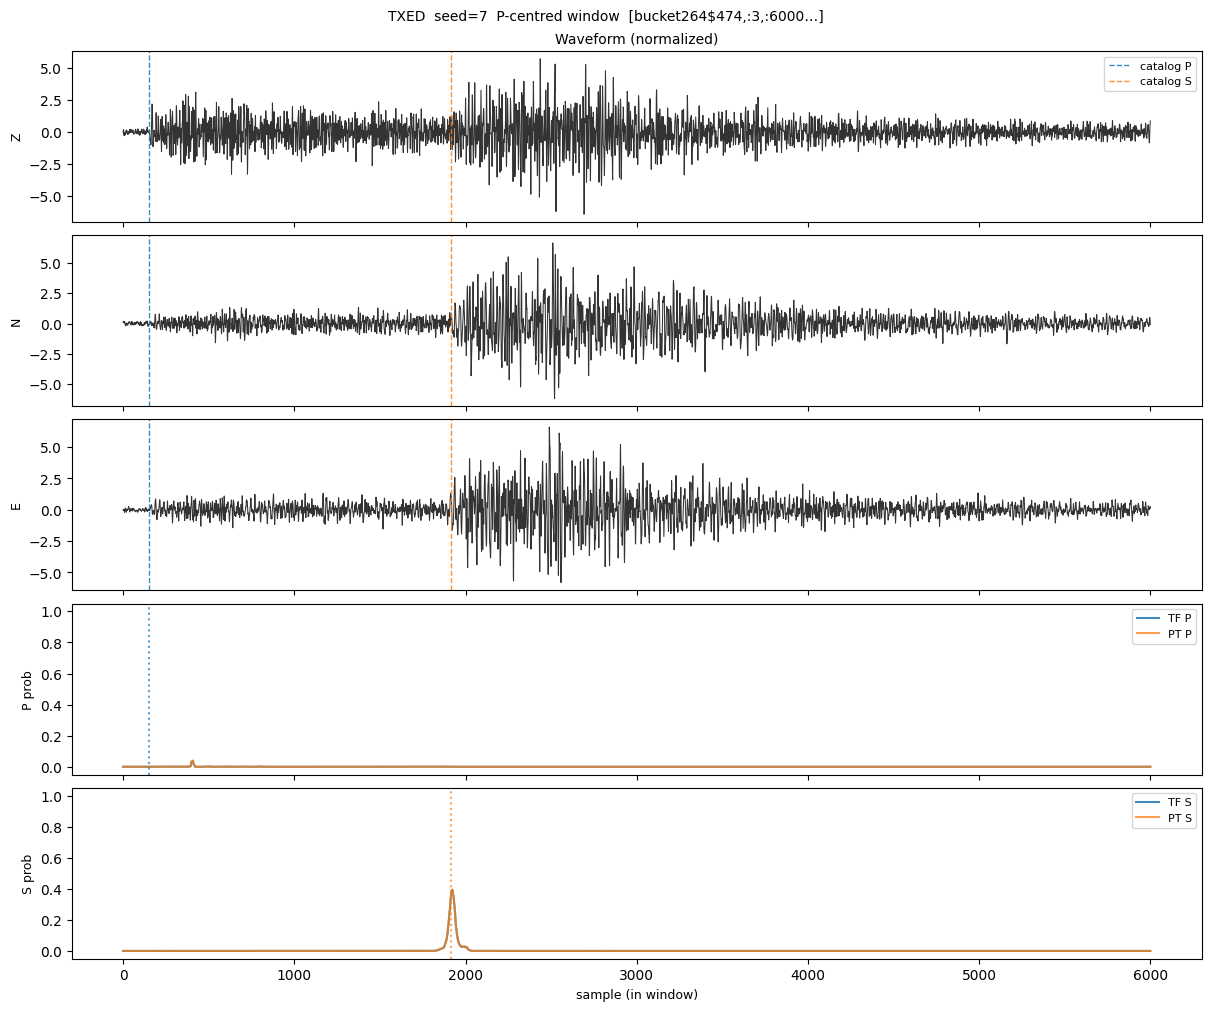

seed  8  P: max|TF-PT|=0.0000 argmax TF=367 PT=367 catP=516  |  S: max|TF-PT|=0.0000 argmax TF=636 PT=636 catS=642
         trace='bucket443$988,:3,:6000'…  window_start=0


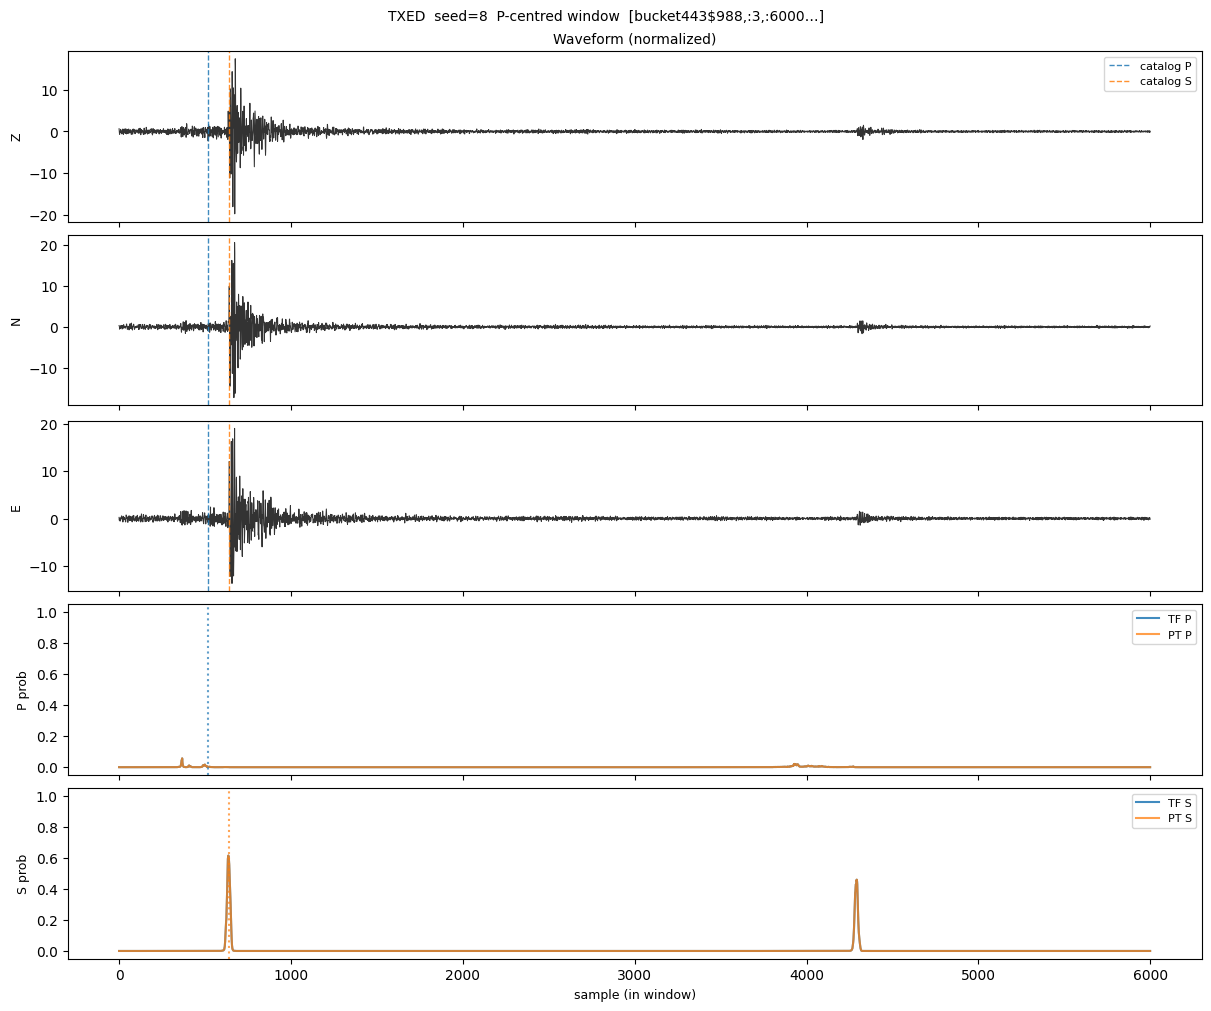

seed  9  P: max|TF-PT|=0.0000 argmax TF=400 PT=400 catP=370  |  S: max|TF-PT|=0.0000 argmax TF=1065 PT=1065 catS=915
         trace='bucket317$814,:3,:6000'…  window_start=0


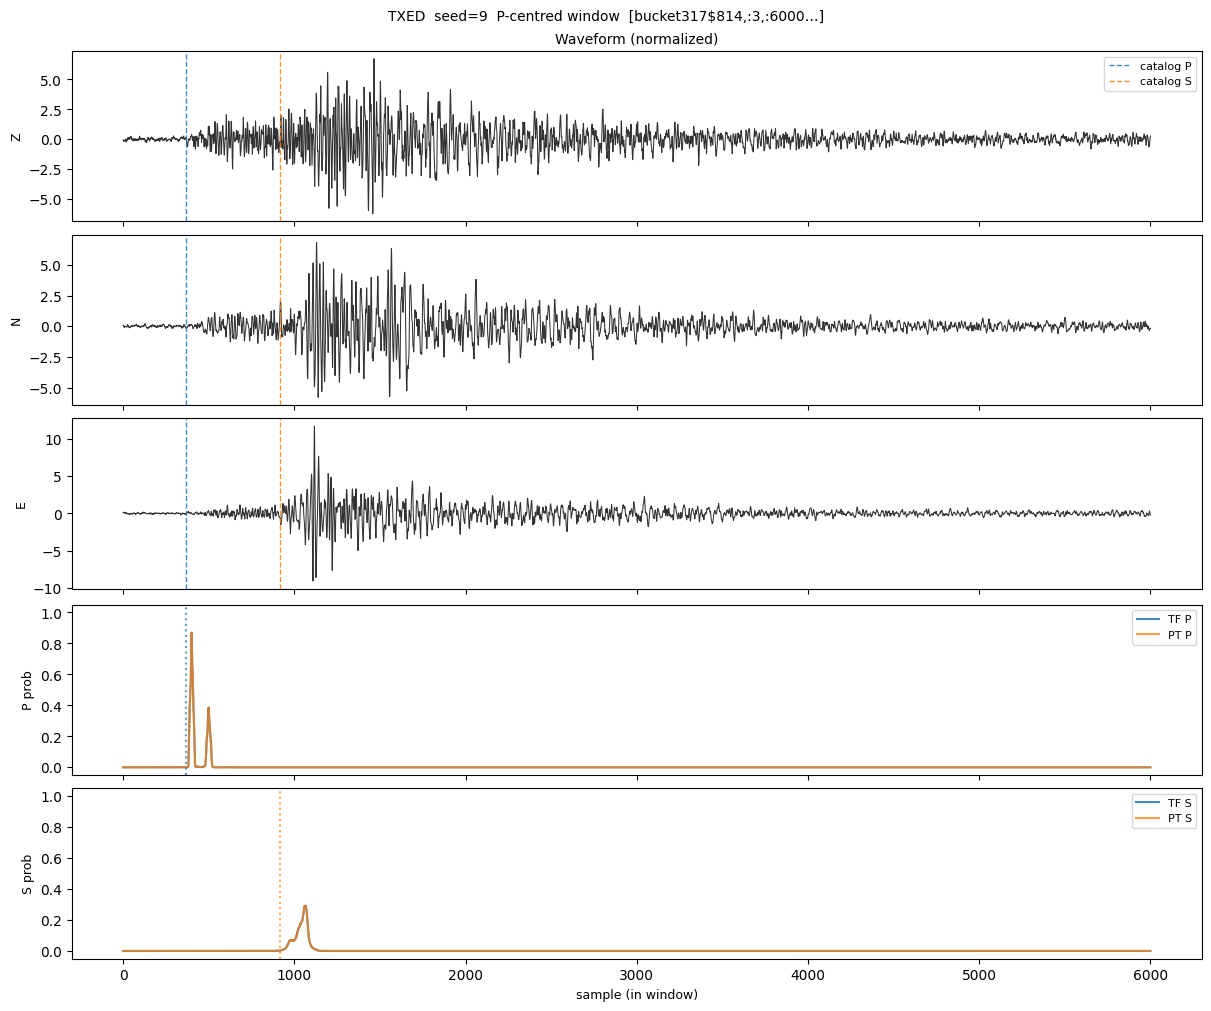

In [4]:
summary = []

for shuffle_seed in SHUFFLE_SEEDS:
    trace_name, wf, p_in, s_in, src_start = window_for_shuffle_seed(shuffle_seed)

    out_p_tf = model_p_tf(wf, training=False)
    p_tf = out_p_tf.numpy() if hasattr(out_p_tf, "numpy") else np.asarray(out_p_tf)
    if p_tf.ndim == 3:
        p_tf = p_tf[..., 0]

    out_s_tf = model_s_tf(wf, training=False)
    s_tf = out_s_tf.numpy() if hasattr(out_s_tf, "numpy") else np.asarray(out_s_tf)
    if s_tf.ndim == 3:
        s_tf = s_tf[..., 0]

    with torch.no_grad():
        p_pt = model_p_pt(torch.from_numpy(wf)).numpy()[..., 0]
        s_pt = model_s_pt(torch.from_numpy(wf)).numpy()[..., 0]

    d_p = np.abs(p_tf - p_pt)
    d_s = np.abs(s_tf - s_pt)
    summary.append(
        {
            "seed": shuffle_seed,
            "trace": trace_name,
            "src_start": src_start,
            "p_cat": p_in,
            "s_cat": s_in,
            "p_maxdiff": float(d_p.max()),
            "s_maxdiff": float(d_s.max()),
            "p_argmax_tf": int(p_tf[0].argmax()),
            "p_argmax_pt": int(p_pt[0].argmax()),
            "s_argmax_tf": int(s_tf[0].argmax()),
            "s_argmax_pt": int(s_pt[0].argmax()),
        }
    )

    print(
        f"seed {shuffle_seed:2d}  P: max|TF-PT|={d_p.max():.4f} argmax TF={p_tf[0].argmax()} PT={p_pt[0].argmax()} catP={p_in}  |  "
        f"S: max|TF-PT|={d_s.max():.4f} argmax TF={s_tf[0].argmax()} PT={s_pt[0].argmax()} catS={s_in}"
    )
    print(f"         trace={trace_name[:72]!r}…  window_start={src_start}")

    fig, axes = plt.subplots(5, 1, figsize=(12, 10), sharex=True, layout="constrained")
    ch_labels = ["Z", "N", "E"]
    for k in range(3):
        ax = axes[k]
        ax.plot(wf[0, :, k], color="0.2", lw=0.75)
        if k == 0:
            ax.axvline(p_in, color="C0", ls="--", lw=1.0, alpha=0.85, label="catalog P")
            ax.axvline(s_in, color="C1", ls="--", lw=1.0, alpha=0.85, label="catalog S")
            ax.legend(loc="upper right", fontsize=8)
        else:
            ax.axvline(p_in, color="C0", ls="--", lw=1.0, alpha=0.85)
            ax.axvline(s_in, color="C1", ls="--", lw=1.0, alpha=0.85)
        ax.set_ylabel(ch_labels[k], fontsize=9)
    axes[0].set_title("Waveform (normalized)", fontsize=10)

    axes[3].plot(p_tf[0], label="TF P", alpha=0.85)
    axes[3].plot(p_pt[0], label="PT P", alpha=0.75)
    axes[3].axvline(p_in, color="C0", ls=":", alpha=0.7)
    axes[3].set_ylabel("P prob", fontsize=9)
    axes[3].set_ylim(-0.05, 1.05)
    axes[3].legend(loc="upper right", fontsize=8)

    axes[4].plot(s_tf[0], label="TF S", alpha=0.85)
    axes[4].plot(s_pt[0], label="PT S", alpha=0.75)
    axes[4].axvline(s_in, color="C1", ls=":", alpha=0.7)
    axes[4].set_ylabel("S prob", fontsize=9)
    axes[4].set_ylim(-0.05, 1.05)
    axes[4].set_xlabel("sample (in window)", fontsize=9)
    axes[4].legend(loc="upper right", fontsize=8)

    fig.suptitle(
        f"{ds_name}  seed={shuffle_seed}  P-centred window  [{trace_name[:56]}…]",
        fontsize=10,
    )
    plt.show()